In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..', '..')))

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from yb_analysis.analysis.load_data import load_latest_scan, load_scan_from_path, list_scans, load_images, get_images_shape
from yb_analysis.analysis.unpack import unpack_scan_logicals
from yb_analysis.analysis import probabilities as prob
from yb_analysis.analysis import fitting
from yb_analysis.analysis import plotting

# MATLAB-style for static matplotlib plots
plotting.apply_matlab_style()

## Load data

### latest

In [23]:
# Load the latest scan data according to the naming rule of saved path
data = load_latest_scan()
Scan = data['Scan']
logicals = data['logicals']
seq_ids = data['seq_ids']
matPath = data['path']
scan_name_raw = Scan.get('ScanName', {}).get('scanname')
scanName = ''.join(chr(int(c)) for c in np.asarray(scan_name_raw).ravel() if c > 0) if scan_name_raw is not None else os.path.basename(matPath)
# For 1D scan with 2 images per sequence, unpack the scan data
scan_params, logic1, logic2 = unpack_scan_logicals(Scan, logicals, seq_ids,
                                                    mat_path=data.get('mat_path'))
# Get the atom survival rate from the unpacked data
p11_sr, p11_sem_sr = prob.prob11_site_resolved(logic1, logic2)
p11_mean, p11_sem = prob.prob11(logic1, logic2)


from yb_analysis.detection.scan_analysis import extract_scan_dims_h5
scan_dims = extract_scan_dims_h5(data.get("mat_path")) if data.get("mat_path") else None
print(f'Loaded: {matPath}')
print(f'Sites: {logic1.shape[0]}, Params: {len(scan_params)}, Reps: {logic1.shape[2]}')

Loaded: D:\OneDrive - Harvard University\Documents - Yb\Data\20260413\data_20260413_155013\data_20260413_155013.h5
Sites: 22, Params: 5, Reps: 6


### Load a specific folder

In [138]:
# Or load scan data from a path
dataDir = r"D:\OneDrive - Harvard University\Documents - Yb\Data\20260410\data_20260410_143926"

data = load_scan_from_path(dataDir)
Scan = data['Scan']
logicals = data['logicals']
seq_ids = data['seq_ids']
matPath = data['path']
scan_name_raw = Scan.get('ScanName', {}).get('scanname')
scanName = ''.join(chr(int(c)) for c in np.asarray(scan_name_raw).ravel() if c > 0) if scan_name_raw is not None else os.path.basename(matPath)

# For 1D scan with 2 images per sequence, unpack the scan data
scan_params, logic1, logic2 = unpack_scan_logicals(Scan, logicals, seq_ids,
                                                    mat_path=data.get('mat_path'))

# Get the atom survival rate from the unpacked data
p11_sr, p11_sem_sr = prob.prob11_site_resolved(logic1, logic2)
p11_mean, p11_sem = prob.prob11(logic1, logic2)

from yb_analysis.detection.scan_analysis import extract_scan_dims_h5
scan_dims = extract_scan_dims_h5(data.get("mat_path")) if data.get("mat_path") else None


## Load images lazily (for large files)
Use `load_images(path, frames)` to load only specific frames without reading the full dataset into memory. This works for files of any size.

## Plot without fitting

In [3]:
# 1D scan plot of the survival rate â€” no fitting
x = scan_params

scan_name_raw = Scan.get('ScanName', {}).get('scanname')
scanName = ''.join(chr(int(c)) for c in np.asarray(scan_name_raw).ravel() if c > 0) if scan_name_raw is not None else 'Scan'

fig = plotting.plot_scan_interactive(x, p11_mean, p11_sem,
                                      xlabel='Time (us)', ylabel='Survival Rate',
                                      title=scanName, data_path=matPath)
#fig.update_xaxes(title_text='MW Freq (MHz)')
#fig.update_xaxes(title_text='556 Detuning (Hz)')
#fig.update_xaxes(title_text='616 EOM Freq (Hz)')
fig.show()

# Save static version
outDir = os.path.dirname(matPath)
plotting.plot_scan(x, p11_mean, p11_sem, xlabel='Time (s)', ylabel='Survival Rate',
                   title=scanName, data_path=matPath)[0].savefig(
    os.path.join(outDir, scanName + '.png'), dpi=150, bbox_inches='tight')
plt.close()

In [7]:
# 2D heatmap of loading rate
lr_mean, lr_sem = prob.loading_rate(logic1)

if scan_params.ndim == 2 and scan_params.shape[1] == 2:
    plotting.heatmap_2d_scan(scan_params, lr_mean,
                              ylabel='Bias Coil Y', xlabel='Bias Coil X',
                              title='Loading Rate')
else:
    print('Not a 2D scan skipping heatmap')

Not a 2D scan skipping heatmap


## STIRAP 2D scan

In [292]:
# 2D scan heatmap of the survival rate
if scan_params.ndim == 2 and scan_params.shape[1] == 2:
    xlabel = scan_dims[0]["name"] if scan_dims and len(scan_dims) >= 2 else "Dim 0"
    ylabel = scan_dims[1]["name"] if scan_dims and len(scan_dims) >= 2 else "Dim 1"
    fig = plotting.heatmap_2d_interactive(scan_params, p11_mean,
                                           title="STIRAP 2D Scan",
                                           xlabel=xlabel, ylabel=ylabel)
    fig.show()
    
    best_idx = np.nanargmax(p11_mean)
    print(f"Peak survival = {p11_mean[best_idx]:.4f} at params = {scan_params[best_idx]}")
    
    # Save static PNG
    outDir = os.path.dirname(matPath)
    plotting.heatmap_2d_scan(scan_params, p11_mean, title="STIRAP 2D Scan",
                              xlabel=xlabel, ylabel=ylabel, cmap="cividis")[0].savefig(
        os.path.join(outDir, scanName + ".png"), dpi=150, bbox_inches="tight")
    plt.close()
else:
    print("Not a 2D scan")

Peak survival = 0.6600 at params = [  0.7 131.5]


## 556 Cooling 2D scan

Peak survival = 0.7597 at params = [1.2e+02 1.1e-01]


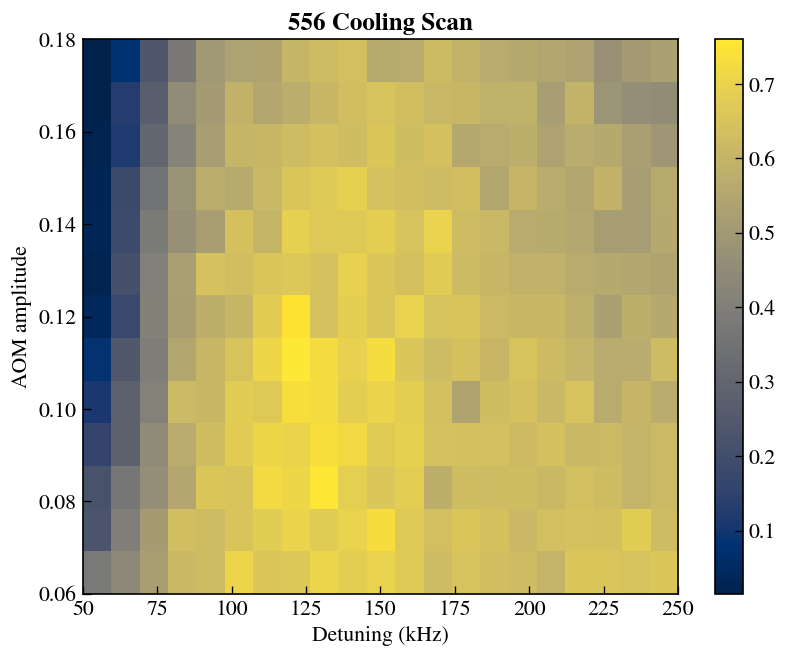

In [83]:
# 2D scan heatmap of the survival rate â€” 556 Cooling
if scan_params.ndim == 2 and scan_params.shape[1] == 2:
    # Convert x-axis from frequency to detuning (kHz)
    # C = Consts().Resonance556mj0Freq  # offset in Hz
    C = 0  # set resonance frequency here
    
    sp_display = scan_params.copy()
    sp_display[:, 0] = (sp_display[:, 0] - C) / 1e3  # to kHz
    
    fig, ax = plotting.heatmap_2d_scan(sp_display, p11_mean,
                                        title='556 Cooling Scan',
                                        xlabel='Detuning (kHz)',
                                        ylabel='AOM amplitude',
                                        cmap='cividis')
    
    best_idx = np.nanargmax(p11_mean)
    print(f'Peak survival = {p11_mean[best_idx]:.4f} at params = {sp_display[best_idx]}')
else:
    print('Not a 2D scan')

In [ ]:
# Site-resolved survival spatial plot
grid_x = np.asarray(Scan.get('initGridLocationsX', [])).ravel()
grid_y = np.asarray(Scan.get('initGridLocationsY', [])).ravel()
grid = np.column_stack([grid_y, grid_x]) if len(grid_x) > 0 else None

# Average survival across all params for each site
avg_survival = np.nanmean(p11_sr, axis=1)
avg_sem = np.sqrt(np.nansum(p11_sem_sr**2, axis=1)) / p11_sr.shape[1]

if grid is not None:
    plotting.plot_site_data(avg_survival, grid, data_sem=avg_sem,
                            title='Survival vs. Site Index',
                            cmap='RdYlGn', clim=(0, 1))

## Loading rate

In [ ]:
# 1D averaged plot â€” loading rate vs scanParams
lr_mean, lr_sem = prob.loading_rate(logic1)

fig = plotting.plot_scan_interactive(scan_params, lr_mean, lr_sem,
                                      xlabel='556 AOM Freq Detuning (Hz)', ylabel='Loading Rate',
                                      title=scanName, data_path=matPath)
fig.show()

In [ ]:
# Site-resolved loading rate â€” spatial map
lr_sr, lr_sem_sr = prob.loading_rate_site_resolved(logic1)

lr_mean_siteAvg = np.nanmean(lr_sr, axis=1)  # average each site over nParams
n_params = lr_sem_sr.shape[1]
lr_sem_siteAvg = np.sqrt(np.nansum(lr_sem_sr**2, axis=1)) / n_params

if grid is not None:
    plotting.plot_site_data(lr_mean_siteAvg, grid, data_sem=lr_sem_siteAvg,
                            title='Loading Rate vs. Site Index',
                            cmap='RdYlGn', clim=(0, 1))

## Rabi oscillation

In [4]:
# Fit damped sinusoidal to Rabi oscillation data
from scipy.optimize import curve_fit

def sinexp_model(x, y0, A, T, tau, phi, x0=0):
    """y = y0 + A * sin(2π*(x-x0)/T + φ) * exp(-(x-x0)/τ)"""
    return y0 + A * np.sin(2*np.pi*(x - x0)/T + phi) * np.exp(-(x - x0)/tau)

N = 40
N = min(N, len(scan_params))  # ensure we don't exceed available data
x = scan_params[0:N]
y = p11_mean[0:N]
yerr = p11_sem[0:N]

# Drop NaN/Inf points (no data for those scan params)
valid = np.isfinite(x) & np.isfinite(y)
x, y, yerr = x[valid], y[valid], yerr[valid]

y0_g = np.mean(y)
A_g = (np.max(y) - np.min(y)) / 2
T_g = 1/2e6 #(x.max() - x.min()) / 3
tau_g = (x.max() - x.min())
phi_g = 0

try:
    popt, pcov = curve_fit(sinexp_model, x, y, p0=[y0_g, A_g, T_g, tau_g, phi_g],
                           maxfev=10000)
    x_fit = np.linspace(x.min(), x.max(), 500)
    y_fit = sinexp_model(x_fit, *popt)
    
    fit_label = f'Sin·Exp f={1/popt[2]:.4g}, τ={popt[3]:.4g}'
    fig = plotting.plot_rabi_interactive(x, y, yerr, x_fit, y_fit, fit_label,
                                          xlabel='Time (s)', title='Microwave Rabi Oscillations',
                                          data_path=matPath)
    fig.show()
    print(f'Fit: f={1/popt[2]:.4g}, τ={popt[3]:.4g}, A={popt[1]:.4g}')
except Exception as e:
    print(f'Rabi fit failed: {e}')

Fit: f=2.464e+06, τ=2.078e-06, A=-0.2196


In [9]:
# Damped Rabi with separate T1 (population relaxation) and T2 (dephasing)
#   y(t) = y_inf + B*exp(-t/T1) + A*sin(2*pi*t/T + phi)*exp(-t/T2)
#
# At t->inf:  y -> y_inf  (steady-state survival, typically ~0.5)
# At t=0:     y = y_inf + B + A*sin(phi)
# T1 controls how fast the mean drifts to y_inf
# T2 controls how fast oscillations damp out (T2 <= 2*T1 physically)

from scipy.optimize import curve_fit

def rabi_T1T2_model(x, y_inf, B, T1, A, T, T2, phi):
    return y_inf + B * np.exp(-x / T1) + A * np.sin(2*np.pi*x / T + phi) * np.exp(-x / T2)

x = scan_params.copy()
y = p11_mean.copy()
yerr = p11_sem.copy()

# Drop NaN/Inf points (no data for those scan params)
valid = np.isfinite(x) & np.isfinite(y)
x, y, yerr = x[valid], y[valid], yerr[valid]

# --- Initial guesses ---
# User knows Rabi freq ~ 5 MHz => T ~ 200 ns
f_rabi_guess = 5e6                                   # Hz — adjust if needed
T_g     = 1.0 / f_rabi_guess                        # ~2e-7 s
y_inf_g = 0.5                                        # two-level system steady state
B_g     = 0.5                                        # starts at ~1, decays to ~0.5
A_g     = 0.4                                        # large initial oscillation amplitude
T1_g    = (x.max() - x.min())                       # slow relaxation
T2_g    = (x.max() - x.min()) / 2                   # faster dephasing
phi_g   = 0.0

p0 = [y_inf_g, B_g, T1_g, A_g, T_g, T2_g, phi_g]

# Bounds: constrain T near the expected Rabi period
lb = [0,   -1, 1e-15, 0.05, T_g/5,  1e-15, -2*np.pi]
ub = [1.5,  1, np.inf, 1,   T_g*5,  np.inf, 2*np.pi]

# Use sigma only if all values are finite and positive
use_sigma = np.all(np.isfinite(yerr) & (yerr > 0))

try:
    popt, pcov = curve_fit(rabi_T1T2_model, x, y, p0=p0, bounds=(lb, ub),
                           sigma=yerr if use_sigma else None,
                           maxfev=20000)
    perr = np.sqrt(np.diag(pcov))
    x_fit = np.linspace(x.min(), x.max(), 500)
    y_fit = rabi_T1T2_model(x_fit, *popt)

    names = ['y_inf', 'B', 'T1', 'A', 'T', 'T2', 'phi']
    for n, v, e in zip(names, popt, perr):
        print(f'  {n:>5s} = {v:.4g}  +/- {e:.4g}')
    print(f'  Rabi freq = {1/popt[4]:.4g} Hz = {1/popt[4]/1e6:.4g} MHz')

    fit_label = f'T1={popt[2]:.4g}, T2={popt[5]:.4g}, f_Rabi={1/popt[4]/1e6:.3f} MHz'
    fig = plotting.plot_rabi_interactive(x, y, yerr, x_fit, y_fit, fit_label,
                                          xlabel='Time (s)', title='Rabi (T1/T2 model)',
                                          data_path=matPath)
    fig.show()
except Exception as e:
    print(f'Rabi T1/T2 fit failed: {e}')
    print(f'Initial guesses: {dict(zip(["y_inf","B","T1","A","T","T2","phi"], p0))}')

  y_inf = 0.004411  +/- 4.985
      B = 0.639  +/- 4.965
     T1 = 3.398e-05  +/- 0.0003051
      A = 0.1445  +/- 0.02311
      T = 3.805e-07  +/- 4.463e-09
     T2 = 5.388e-06  +/- 2.706e-06
    phi = 6.283  +/- 0.1925
  Rabi freq = 2.628e+06 Hz = 2.628 MHz


In [10]:
# Fit damped sinusoidal with steady-state recovery term
from scipy.optimize import curve_fit

def sinexp_recovery_model(x, y0, A, T, tau, phi, x0=0):
    """y = y0 + A * sin(2π*(x-x0)/T + φ) * exp(-(x-x0)/τ) + (1 - exp(-(x-x0)/τ))"""
    return y0 + A * np.sin(2*np.pi*(x - x0)/T + phi) * np.exp(-(x - x0)/tau) + (1 - np.exp(-(x - x0)/tau))

x = scan_params.copy()
y = p11_mean.copy()
yerr = p11_sem.copy()

# Drop NaN/Inf points (no data for those scan params)
valid = np.isfinite(x) & np.isfinite(y)
x, y, yerr = x[valid], y[valid], yerr[valid]

y0_g = np.mean(y)
A_g = (np.max(y) - np.min(y)) / 2
T_g = (x.max() - x.min()) / 3
tau_g = (x.max() - x.min())
phi_g = 0

try:
    popt, pcov = curve_fit(sinexp_recovery_model, x, y, p0=[y0_g, A_g, T_g, tau_g, phi_g],
                           maxfev=10000)
    x_fit = np.linspace(x.min(), x.max(), 500)
    y_fit = sinexp_recovery_model(x_fit, *popt)
    
    fit_label = f'Sin·Exp+Recovery fit; T={popt[2]:.4g}, τ={popt[3]:.4g}'
    fig = plotting.plot_rabi_interactive(x, y, yerr, x_fit, y_fit, fit_label,
                                          xlabel='Time (s)', title='Microwave Rabi Oscillations',
                                          data_path=matPath)
    fig.show()
    print(f'Fit: T={popt[2]:.4g}, τ={popt[3]:.4g}, A={popt[1]:.4g}')
except Exception as e:
    print(f'Rabi fit failed: {e}')

Fit: T=-2.397e-08, τ=1121, A=0.03475


## Single-site Rabi oscillation

In [252]:
# Rabi oscillation for a single site
site_idx = 5  # <-- change this to pick a different site

x = scan_params.copy()
y_site = p11_sr[site_idx].copy()
sem_site = p11_sem_sr[site_idx].copy()

# Drop NaN/Inf points (no data for those scan params)
valid = np.isfinite(x) & np.isfinite(y_site)
x, y_site, sem_site = x[valid], y_site[valid], sem_site[valid]

# Fit T1/T2 model to this site
f_rabi_guess = 5e6
T_g = 1.0 / f_rabi_guess

p0 = [0.5, 0.5, (x.max()-x.min()), 0.4, T_g, (x.max()-x.min())/2, 0.0]
lb = [0,   -1, 1e-15, 0.05, T_g/5,  1e-15, -2*np.pi]
ub = [1.5,  1, np.inf, 1,   T_g*5,  np.inf, 2*np.pi]

use_sigma = np.all(np.isfinite(sem_site) & (sem_site > 0))

try:
    popt, pcov = curve_fit(rabi_T1T2_model, x, y_site, p0=p0, bounds=(lb, ub),
                           sigma=sem_site if use_sigma else None,
                           maxfev=20000)
    perr = np.sqrt(np.diag(pcov))
    x_fit = np.linspace(x.min(), x.max(), 500)
    y_fit = rabi_T1T2_model(x_fit, *popt)

    names = ['y_inf', 'B', 'T1', 'A', 'T', 'T2', 'phi']
    for n, v, e in zip(names, popt, perr):
        print(f'  {n:>5s} = {v:.4g}  +/- {e:.4g}')
    print(f'  Rabi freq = {1/popt[4]/1e6:.4g} MHz')

    fit_label = f'Site {site_idx}: T2={popt[5]:.4g}, f_Rabi={1/popt[4]/1e6:.3f} MHz'
    fig = plotting.plot_rabi_interactive(x, y_site, sem_site, x_fit, y_fit, fit_label,
                                          xlabel='Time (s)', title=f'Rabi — Site {site_idx}',
                                          data_path=matPath)
    fig.show()
except Exception as e:
    # Plot without fit
    print(f'Fit failed for site {site_idx}: {e}')
    fig = plotting.plot_scan_interactive(x, y_site, sem_site,
                                          xlabel='Time (s)', ylabel='Survival Rate',
                                          title=f'Rabi — Site {site_idx}', data_path=matPath)
    fig.show()

  y_inf = 0.5467  +/- 0.07064
      B = 0.2215  +/- 0.06278
     T1 = 3.496e-06  +/- 2.841e-06
      A = 0.17  +/- 0.1506
      T = 2.201e-07  +/- 3.18e-08
     T2 = 6.261e-07  +/- 1.353e-06
    phi = -1.616  +/- 1.444
  Rabi freq = 4.544 MHz


## Fitting a sine to Ramsey (omega fixed = 1)

In [ ]:
# Model: y = A*sin(x + φ) + C
def sin_model(x, A, phi, C):
    return A * np.sin(x + phi) + C

x = scan_params
y = p11_mean
err = p11_sem

A0 = (np.max(y) - np.min(y)) / 2
phi0 = 0
C0 = np.mean(y)

try:
    popt, pcov = curve_fit(sin_model, x, y, p0=[A0, phi0, C0])
    A, phi, C = popt
    Aphys = abs(A)
    Aerr = np.sqrt(pcov[0, 0])
    
    x_fit = np.linspace(x.min(), x.max(), 500)
    y_fit = sin_model(x_fit, *popt)
    
    fit_label = f'Sine fit; |A|={Aphys:.4f}Â±{Aerr:.4f}'
    fig = plotting.plot_rabi_interactive(x, y, err, x_fit, y_fit, fit_label,
                                          xlabel='Phase (rad)', title=scanName,
                                          data_path=matPath)
    fig.show()
    print(f'Fit: A={A:.6f} (|A|={Aphys:.6f}), φ={phi:.6f} rad, C={C:.6f}')
except Exception as e:
    print(f'Sine fit failed: {e}')

## Fit to a Lorentzian

### peak

In [276]:
# Plot and fit a Lorentzian peak
lor_fit = fitting.fit_lorentzian(scan_params, p11_mean, p11_sem, mode='peak')
if lor_fit:
    fig = plotting.plot_scan_interactive(scan_params, p11_mean, p11_sem, fit_result=lor_fit,
                                          xlabel='616 EOM Frequency (Hz)', ylabel='Survival Rate',
                                          title=scanName, data_path=matPath)
    fig.show()
    
    y0, A, x0, w = lor_fit['params']
    print(f'Fit params: yâ‚€={y0:.4g}, A={A:.4g}, xâ‚€={x0:.5g}, w={w:.4g}')
    print(f'Center: {x0:.5g} Hz, Width: {w:.4g} Hz, RÂ² = {lor_fit["r_squared"]:.4f}')
    
    # Save static PNG
    outDir = os.path.dirname(matPath)
    plotting.plot_scan(scan_params, p11_mean, p11_sem, fit_result=lor_fit,
                       xlabel='616 EOM Frequency (Hz)', ylabel='Survival Rate',
                       title=scanName, data_path=matPath)[0].savefig(
        os.path.join(outDir, scanName + '.png'), dpi=150, bbox_inches='tight')
    plt.close()

Fit params: yâ‚€=0.05353, A=0.9289, xâ‚€=2.7081e+08, w=3.58e+06
Center: 2.7081e+08 Hz, Width: 3.58e+06 Hz, RÂ² = 0.9509


C:\Users\Ybtweezer-PC2\AppData\Local\Temp\ipykernel_17352\7013788.py:17: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) STIXGeneral.
  title=scanName, data_path=matPath)[0].savefig(


### dip

In [297]:
# Plot and fit a Lorentzian dip
lor_fit_dip = fitting.fit_lorentzian(scan_params, p11_mean, p11_sem, mode='dip')
if lor_fit_dip:
    fig = plotting.plot_scan_interactive(scan_params, p11_mean, p11_sem, fit_result=lor_fit_dip,
                                          xlabel='Frequency (Hz)', ylabel='Survival Rate',
                                          title=scanName, data_path=matPath)
    fig.show()
    
    y0, A, x0, w = lor_fit_dip['params']
    perr = np.sqrt(np.diag(lor_fit_dip['pcov']))
    y0_e, A_e, x0_e, w_e = perr
    print(f'Fit params:')
    print(f'  y₀ = {y0:.4g}  +/- {y0_e:.4g}')
    print(f'   A = {A:.4g}  +/- {A_e:.4g}')
    print(f'  x₀ = {x0:.5g}  +/- {x0_e:.4g}')
    print(f'   w = {w:.4g}  +/- {w_e:.4g}')
    print(f'  R² = {lor_fit_dip["r_squared"]:.4f}')
    
    # Save static PNG
    outDir = os.path.dirname(matPath)
    plotting.plot_scan(scan_params, p11_mean, p11_sem, fit_result=lor_fit_dip,
                       xlabel='Frequency (Hz)', ylabel='Survival Rate',
                       title=scanName, data_path=matPath)[0].savefig(
        os.path.join(outDir, scanName + '.png'), dpi=150, bbox_inches='tight')
    plt.close()

Fit params:
  y₀ = 1.245  +/- 66.01
   A = 0.92  +/- 63.3
  x₀ = 2.7042e+08  +/- 1.258e+07
   w = 1.495e+06  +/- 1.194e+08
  R² = 0.9224


C:\Users\Ybtweezer-PC2\AppData\Local\Temp\ipykernel_17352\1530635862.py:23: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) STIXGeneral.
  title=scanName, data_path=matPath)[0].savefig(


## E-field

In [ ]:
# Plot and fit Lorentzian for 2D grouped scan (E-field calibration)
if scan_params.ndim == 2 and scan_params.shape[1] == 2:
    # Group by first param, fit Lorentzian to second param
    groups = np.unique(scan_params[:, 0])
    fig, ax = plt.subplots(figsize=(10, 6))
    for g in groups:
        mask = scan_params[:, 0] == g
        x_g = scan_params[mask, 1]
        y_g = p11_mean[mask]
        err_g = p11_sem[mask]
        ax.errorbar(x_g, y_g, yerr=err_g, fmt='o-', label=f'Group {g:.2g}')
    ax.set_xlabel('616 EOM Frequency (Hz)')
    ax.set_ylabel('Survival Rate')
    ax.set_title(scanName)
    ax.legend()
    ax.grid(True, alpha=0.3)
else:
    print('Not a 2D scan')

In [ ]:
# E-field calibration: quadratic Stark shift fit
# Data (fill in your measured values)
Vx = np.array([-1, -0.5, 0, 0.5, 1])
f = np.array([284.9, 284.04, 284.14, 284.21, 285.52])

# Fit: f = a*(Vx - b)^2 + f0
def quadratic(x, a, b, f0):
    return a * (x - b)**2 + f0

popt, pcov = curve_fit(quadratic, Vx, f, p0=[0.5, -0.2, 284.0])
a, b, f0 = popt
ss_res = np.sum((f - quadratic(Vx, *popt))**2)
ss_tot = np.sum((f - f.mean())**2)
r2 = 1 - ss_res / ss_tot

print(f'a  = {a:.4f} MHz/VÂ²')
print(f'b  = {b:.5f} V')
print(f'f0 = {f0:.4f} MHz')
print(f'RÂ² = {r2:.6f}')

Vx_fine = np.linspace(Vx.min(), Vx.max(), 300)
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(Vx, f, 'ko', markersize=7, linewidth=1.5, label='Data')
ax.plot(Vx_fine, quadratic(Vx_fine, *popt), 'g-', linewidth=2,
        label=f'Fit: {a:.3f}(Vx - {b:.4f})Â² + {f0:.3f}')
ax.set_xlabel('V_x (V)')
ax.set_ylabel('Frequency (MHz)')
ax.set_title('E-field calibration: quadratic Stark shift (x-axis)')
ax.legend()
ax.axvline(b, color='r', linestyle='--', alpha=0.5, label=f'V_min = {b:.4f} V')
ax.grid(True, alpha=0.3)
plt.show()

## Site-resolved Lorentzian-fitted centers

In [ ]:
# Fit Lorentzian dip to each site
centers, widths, params, site_fits = fitting.fit_lorentzian_site_resolved(
    scan_params, 1 - p11_sr, p11_sem_sr, mode='lorentzian')

# Plot site-resolved scans with fits
pages = plotting.plot_scan_site_resolved(
    scan_params, 1 - p11_sr, p11_sem_sr, fits=site_fits,
    xlabel='Param', ylabel='1 - P11', title_prefix=scanName)

In [ ]:
# Trap depth from light shift
def trap_depth_from_lightshift(delta_nu):
    """Convert excited-state light shift to ground-state trap depth.
    Hard-coded for 532nm tweezer, Yb-174.
    """
    h = 6.62607015e-34
    kB = 1.380649e-23
    # Polarizabilities in Hz/(W/cm^2)
    alpha_s, alpha_t, alpha_g = 22.4, -7.6, 37.9
    mj1, mj0, theta = 1, 0, 0
    alpha_e1 = alpha_s + alpha_t * (3*np.cos(theta)**2 - 1)/2 * (3*mj1**2 - 2)/(2*2 - 1)
    alpha_e0 = alpha_s + alpha_t * (3*np.cos(theta)**2 - 1)/2 * (3*mj0**2 - 2)/(2*2 - 1)
    I = -4 * delta_nu / (alpha_e1 - alpha_e0)
    depth_Hz = 0.25 * alpha_g * I
    depth_K = h * depth_Hz / kB
    return depth_K, depth_Hz

# Compute trap depth from fitted centers
resonance_freq = 107.33e6  # Hz â€” set to your 556nm resonance
delta_nu = 2 * (resonance_freq - centers)  # Hz
depth_K, depth_Hz = trap_depth_from_lightshift(delta_nu)

if grid is not None:
    plotting.plot_site_data(depth_K, grid,
                            title='Trap Depth vs. Site Index',
                            cmap='viridis')
    print(f'Mean trap depth: {np.nanmean(depth_K):.4g} K')

In [ ]:
# Plot site-resolved fitted centers spatially
if grid is not None:
    plotting.plot_site_data(centers, grid, data_sem=widths,
                            title=f'{scanName}: Fitted Resonant Frequency',
                            cmap='coolwarm')

## Autler-Townes

In [133]:
# Double Lorentzian fit (Autler-Townes splitting) — averaged across array
from scipy.optimize import curve_fit

y = p11_mean
yerr = p11_sem
x = scan_params

# Ensure 1-D and matched lengths (guard against shape mismatches)
x, y, yerr = np.ravel(x), np.ravel(y), np.ravel(yerr)
mask = np.isfinite(x) & np.isfinite(y)
x, y, yerr = x[mask], y[mask], yerr[mask]

y0_g = np.median(y)
# Find first dip
idx1 = np.argmin(y)
x01_g = x[idx1]
A1_g = y0_g - y[idx1]

# Find second dip: mask out region around first, then find min
mask_radius = (x.max() - x.min()) / 6
mask2 = np.abs(x - x01_g) > mask_radius
if mask2.any():
    idx2 = np.where(mask2)[0][np.argmin(y[mask2])]
else:
    idx2 = len(x) - 1 - idx1
x02_g = x[idx2]
A2_g = y0_g - y[idx2]

w_g = (x.max() - x.min()) / 20  # narrower width guess

popt, pcov = curve_fit(fitting.double_lorentzian_dip, x, y,
                        p0=[y0_g, A1_g, x01_g, w_g, A2_g, x02_g, w_g],
                        sigma=yerr, absolute_sigma=True, maxfev=10000)
perr = np.sqrt(np.diag(pcov))

y0, A1, x01, w1, A2, x02, w2 = popt
splitting = abs(x02 - x01)
print(f'Dip 1: x0={x01:.4g}, w={w1:.4g}, A={A1:.4g}')
print(f'Dip 2: x0={x02:.4g}, w={w2:.4g}, A={A2:.4g}')
print(f'AT splitting: {splitting:.4g}')

x_fit = np.linspace(x.min(), x.max(), 500)
y_fit = fitting.double_lorentzian_dip(x_fit, *popt)

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=x, y=y,
    error_y=dict(type='data', array=yerr, visible=True),
    mode='markers', name='data',
    marker=dict(size=7, color='#77AC30'),
))
fig.add_trace(go.Scatter(
    x=x_fit, y=y_fit,
    mode='lines', name=f'Double Lorentzian (Δ={splitting:.4g})',
    line=dict(width=2, color='#D95319'),
))
fig.update_layout(
    title='Autler-Townes: Double Lorentzian Fit (array-averaged)',
    xaxis_title='Scan parameter',
    yaxis_title='Survival probability',
    xaxis=dict(showgrid=False, zeroline=False, showline=True, linecolor='black'),
    yaxis=dict(showgrid=False, zeroline=False, showline=True, linecolor='black'),
    legend=dict(font=dict(size=11), x=0.95, y=1.2, xanchor='right', yanchor='top',
                bgcolor='rgba(255,255,255,0.7)'),
    template='plotly_white',
)
fig.show()


Dip 1: x0=1.433e+08, w=1.424e+05, A=0.504
Dip 2: x0=1.421e+08, w=2e+05, A=0.4593
AT splitting: 1.182e+06


## Site-resolved Autler-Townes

c:\Users\Ybtweezer-PC2\anaconda3\envs\yb_analysis\Lib\site-packages\scipy\optimize\_minpack_py.py:989: RuntimeWarning: divide by zero encountered in divide
  transform = 1.0 / sigma
C:\Users\Ybtweezer-PC2\AppData\Local\Temp\ipykernel_17352\2432642308.py:30: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(fitting.double_lorentzian_dip, x, y,


Mean AT splitting: 1.177e+06 Hz


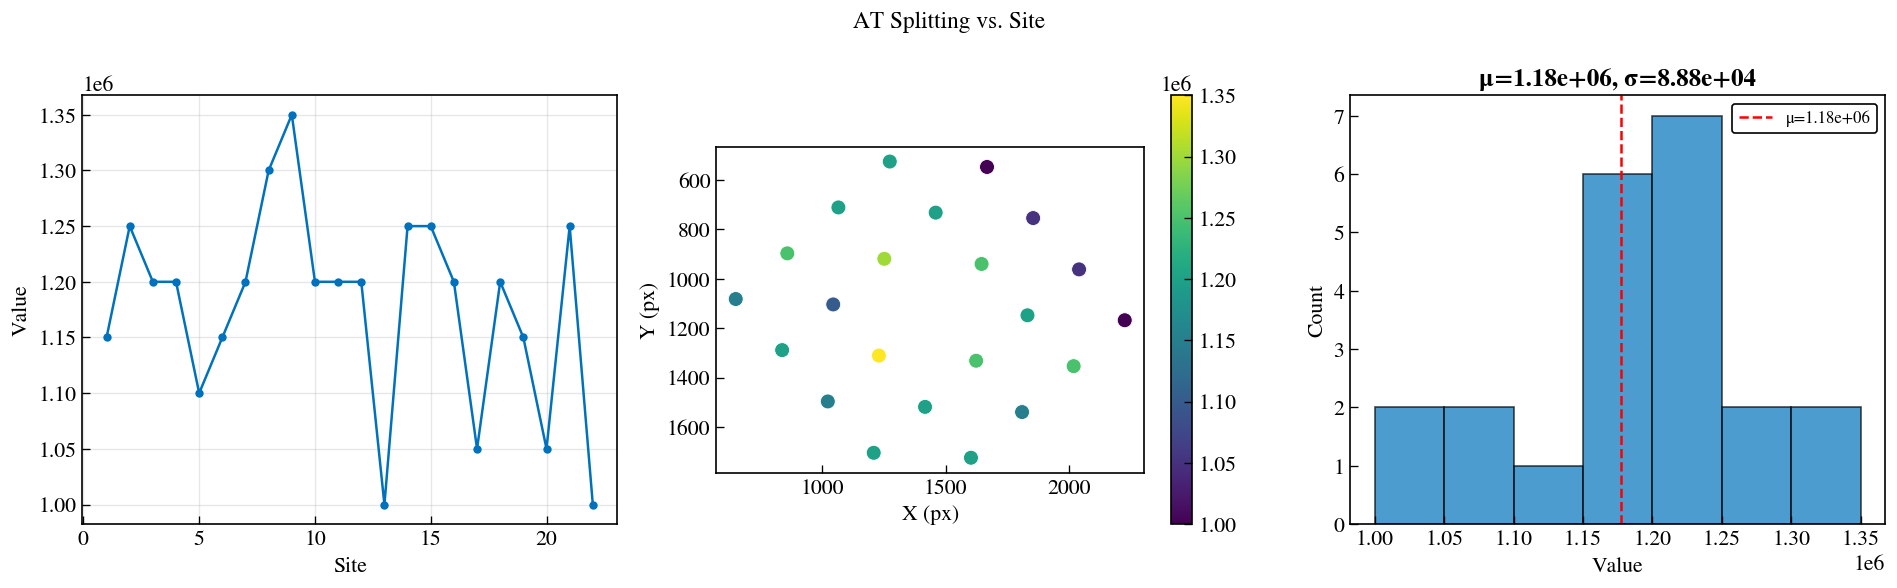

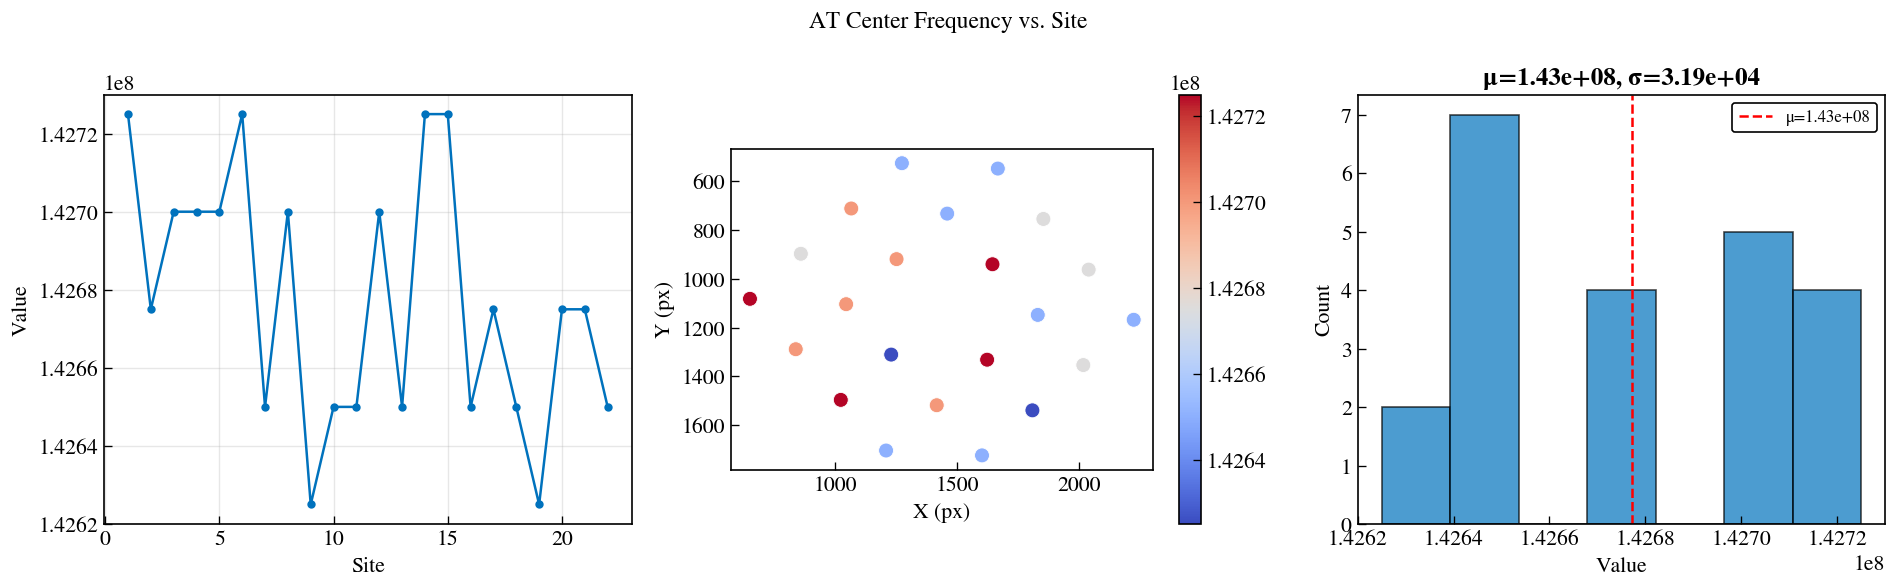

In [136]:
# Autler-Townes: site-resolved splitting — spatial 2D plot
from scipy.optimize import curve_fit

def fit_double_lorentzian_site(x, y, yerr=None):
    """Fit double Lorentzian dip to one site."""
    x, y = np.ravel(x), np.ravel(y)
    if yerr is not None:
        yerr = np.ravel(yerr)
    mask = np.isfinite(x) & np.isfinite(y)
    x, y = x[mask], y[mask]
    if yerr is not None:
        yerr = yerr[mask]

    y0_g = np.median(y)
    idx1 = np.argmin(y)
    x01_g = x[idx1]
    A1_g = y0_g - y[idx1]

    mask_radius = (x.max() - x.min()) / 6
    mask2 = np.abs(x - x01_g) > mask_radius
    if mask2.any():
        idx2 = np.where(mask2)[0][np.argmin(y[mask2])]
    else:
        idx2 = len(x) - 1 - idx1
    x02_g = x[idx2]
    A2_g = y0_g - y[idx2]
    w_g = (x.max() - x.min()) / 20

    try:
        popt, pcov = curve_fit(fitting.double_lorentzian_dip, x, y,
                                p0=[y0_g, A1_g, x01_g, w_g, A2_g, x02_g, w_g],
                                sigma=yerr, absolute_sigma=True, maxfev=10000)
        return popt  # [y0, A1, x01, w1, A2, x02, w2]
    except Exception:
        return None

x = np.ravel(scan_params)
n_sites = p11_sr.shape[0]
at_params = []
for s in range(n_sites):
    result = fit_double_lorentzian_site(x, p11_sr[s], p11_sem_sr[s])
    at_params.append(result)

# Extract splittings
splittings = np.array([abs(p[5] - p[2]) if p is not None else np.nan for p in at_params])
centers_at = np.array([(p[2] + p[5]) / 2 if p is not None else np.nan for p in at_params])
print(f'Mean AT splitting: {np.nanmean(splittings):.4g} Hz')

# ----- Spatial 2D plot -----
grid_x = np.asarray(Scan.get('initGridLocationsX', [])).ravel()
grid_y = np.asarray(Scan.get('initGridLocationsY', [])).ravel()
grid = np.column_stack([grid_y, grid_x]) if len(grid_x) > 0 else None

if grid is not None:
    plotting.plot_site_data(splittings, grid,
                            title='AT Splitting vs. Site',
                            cmap='viridis')
    plotting.plot_site_data(centers_at, grid,
                            title='AT Center Frequency vs. Site',
                            cmap='coolwarm')


## Fit Lorentzian 2D

In [98]:
# Lorentzian fit for 2D grouped scan
if scan_params.ndim == 2 and scan_params.shape[1] == 2:
    groups = np.unique(scan_params[:, 0])
    fig, ax = plt.subplots(figsize=(10, 6))
    for g in groups:
        mask = scan_params[:, 0] == g
        x_g = scan_params[mask, 1]
        y_g = p11_mean[mask]
        err_g = p11_sem[mask]
        line = ax.errorbar(x_g, y_g, yerr=err_g, fmt='o-', label=f'Group {g:.2g}', markersize=4)
        color = line[0].get_color()
        
        lor = fitting.fit_lorentzian(x_g, y_g, err_g, mode='peak')
        if lor:
            y0, A, x0, w = lor['params']
            ax.plot(lor['x_fit'], lor['y_fit'], '--', color=color, alpha=0.7)
            print(f'Group {g:.2g}: center={x0:.4g}, width={w:.4g}, amplitude={A:.4g}, offset={y0:.4g}, R²={lor["r_squared"]:.4f}')
    
    ax.set_xlabel('308 EOM Frequency (Hz)')
    ax.set_ylabel('Survival Rate')
    ax.set_title(scanName)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    
    outDir = os.path.dirname(matPath)
    fig.savefig(os.path.join(outDir, scanName + '.png'), dpi=150, bbox_inches='tight')
else:
    print('Not a 2D scan')

Not a 2D scan


## Fit to an Exponential

In [301]:
# Plot and fit an exponential
exp_fit = fitting.fit_exponential(scan_params, p11_mean, p11_sem)
if exp_fit:
    fig = plotting.plot_scan_interactive(scan_params, p11_mean, p11_sem, fit_result=exp_fit,
                                          xlabel='time (s)', ylabel='Survival Rate',
                                          title=scanName, data_path=matPath)
    fig.update_yaxes(range=[0, 1])
    fig.show()
    
    print(f'Fitted lifetime: τ = {exp_fit["tau"]:.4g} s')
    
    # Save static PNG
    outDir = os.path.dirname(matPath)
    mfig, ax = plotting.plot_scan(scan_params, p11_mean, p11_sem, fit_result=exp_fit,
                                   xlabel='Rydberg time (s)', ylabel='Survival Rate',
                                   title=scanName, data_path=matPath)
    ax.set_ylim([0, 1])
    mfig.savefig(os.path.join(outDir, scanName + '.png'), dpi=150, bbox_inches='tight')
    plt.close()

Fitted lifetime: τ = 2.933e-05 s


## Plot two exponentials together

In [ ]:
# Compare multiple exponential fits on the same axes
# Fill in your data sets:
# x1, y1, sem1 = ...
# x2, y2, sem2 = ...

# fig, ax = plt.subplots(figsize=(10, 6))
# for label, x, y, sem in [('Trap depth ~0uK', x1, y1, sem1),
#                            ('Trap depth ~4uK', scan_params, p11_mean, p11_sem),
#                            ('Trap depth ~35uK', x2, y2, sem2)]:
#     exp = fitting.fit_exponential(x, y, sem)
#     ax.errorbar(x, y, yerr=sem, fmt='o', label=label, markersize=5)
#     if exp:
#         ax.plot(exp['x_fit'], exp['y_fit'], '-', linewidth=1.5)
# ax.set_title('Rydberg lifetime measurement')
# ax.set_ylabel('Survival Rate')
# ax.set_xlabel('Rydberg time (s)')
# ax.legend()
# ax.grid(True, alpha=0.3)
print('Uncomment and fill in data sets to compare exponentials')

## 308 Revival Scan

In [ ]:
# Load and analyze 308 revival scan
# data = load_latest_scan()
# Scan = data['Scan']; logicals = data['logicals']; seq_ids = data['seq_ids']
# scan_params, logic1, logic2 = unpack_scan_logicals(Scan, logicals, seq_ids)
# p11_sr, p11_sem_sr = prob.prob11_site_resolved(logic1, logic2)
# p11_mean, p11_sem = prob.prob11(logic1, logic2)

lor = fitting.fit_lorentzian(scan_params, p11_mean, p11_sem, mode='dip')
if lor:
    fig = plotting.plot_scan_interactive(scan_params, p11_mean, p11_sem, fit_result=lor,
                                          xlabel='308 EOM Frequency (Hz)', ylabel='Survival Rate',
                                          title=scanName, data_path=matPath)
    fig.show()
    
    y0, A, x0, w = lor['params']
    print(f'Fit params: yâ‚€={y0:.4g}, A={A:.4g}, xâ‚€={x0:.5g}, w={w:.4g}')
    print(f'Center: {x0:.5g} Hz, Width: {w:.4g} Hz, RÂ² = {lor["r_squared"]:.4f}')

# Ramsey


## 1D Scan

In [24]:
# 1D Ramsey: fit sinusoid to survival vs phase
from scipy.optimize import curve_fit

def sin_model(x, A, phi, C):
    """y = A*sin(x + φ) + C"""
    return A * np.sin(x + phi) + C

x = scan_params
y = p11_mean
err = p11_sem

A0 = (np.max(y) - np.min(y)) / 2
C0 = np.mean(y)

popt, pcov = curve_fit(sin_model, x, y, p0=[A0, 0, C0],
                       sigma=err, absolute_sigma=True)
A, phi, C = popt
perr = np.sqrt(np.diag(pcov))

x_fit = np.linspace(x.min(), x.max(), 500)
y_fit = sin_model(x_fit, *popt)

contrast = abs(A)
contrast_err = perr[0]

fit_label = f"|A|={contrast:.4f}±{contrast_err:.4f}, φ={phi:.3f}, C={C:.4f}"
fig = plotting.plot_rabi_interactive(x, y, err, x_fit, y_fit, fit_label,
                                     xlabel='Phase (rad)', title=scanName,
                                     data_path=matPath)
fig.show()

print(f"Contrast: {contrast:.6f} ± {contrast_err:.6f}")
print(f"Phase offset: {phi:.4f} rad")
print(f"Offset: {C:.6f}")


Contrast: 0.019610 ± 0.040080
Phase offset: 0.8326 rad
Offset: 0.594045


## 2D (axis 1 = phase, axis 2 = T)

In [19]:
# 2D Ramsey: fit sinusoid at each gap time T, plot all fits + contrast vs T
from scipy.optimize import curve_fit
import plotly.graph_objects as go
from plotly.subplots import make_subplots

def sin_model(x, A, phi, C):
    """y = A*sin(x + φ) + C"""
    return A * np.sin(x + phi) + C

# scan_params[:,0] = gap time T, scan_params[:,1] = phase
T_vals = np.unique(scan_params[:, 1])
contrasts = []
contrast_errs = []

# --- Subplot: sine fits (top) + contrast vs T (bottom) ---
fig = make_subplots(rows=2, cols=1, row_heights=[0.65, 0.35],
                    subplot_titles=["Sine fits per T", "Contrast vs T"],
                    vertical_spacing=0.12)

# colors = plotting.get_plotly_colors(len(T_vals))  # or use a default cycle below
# fallback if helper doesn't exist:
import plotly.express as px; colors = px.colors.qualitative.Plotly * 5

for i, T in enumerate(T_vals):
    mask = scan_params[:, 1] == T
    phase = scan_params[mask, 0]
    surv = p11_mean[mask]
    serr = p11_sem[mask]

    order = np.argsort(phase)
    phase, surv, serr = phase[order], surv[order], serr[order]

    A0 = (np.max(surv) - np.min(surv)) / 2
    C0 = np.mean(surv)
    try:
        popt, pcov = curve_fit(sin_model, phase, surv, p0=[A0, 0, C0],
                               sigma=serr, absolute_sigma=True)
        contrasts.append(abs(popt[0]))
        contrast_errs.append(np.sqrt(pcov[0, 0]))
        phase_fit = np.linspace(phase.min(), phase.max(), 200)
        surv_fit = sin_model(phase_fit, *popt)
    except RuntimeError:
        contrasts.append(np.nan)
        contrast_errs.append(np.nan)
        phase_fit, surv_fit = None, None

    color = colors[i % len(colors)]
    label = f"T={T:.4g}"

    # Data points (visible for first trace only by default)
    fig.add_trace(go.Scatter(
        x=phase, y=surv, error_y=dict(type='data', array=serr, visible=True),
        mode='markers', name=label, legendgroup=label,
        marker=dict(color=color), visible=(True if i == 0 else 'legendonly')
    ), row=1, col=1)

    # Fit curve
    if phase_fit is not None:
        fig.add_trace(go.Scatter(
            x=phase_fit, y=surv_fit, mode='lines',
            name=f"{label} fit", legendgroup=label, showlegend=False,
            line=dict(color=color), visible=(True if i == 0 else 'legendonly')
        ), row=1, col=1)

contrasts = np.array(contrasts)
contrast_errs = np.array(contrast_errs)

# Contrast vs T (always visible)
fig.add_trace(go.Scatter(
    x=T_vals, y=contrasts,
    error_y=dict(type='data', array=contrast_errs, visible=True),
    mode='markers+lines', name='Contrast',
    marker=dict(color='black'), line=dict(color='black')
), row=2, col=1)

fig.update_xaxes(title_text='Phase (rad)', row=1, col=1)
fig.update_yaxes(title_text='Survival', row=1, col=1)
fig.update_xaxes(title_text='Gap time T', row=2, col=1)
fig.update_yaxes(title_text='Contrast', row=2, col=1)
fig.update_layout(height=750, title=f"Ramsey — {scanName}",
                  legend=dict(title="Click to toggle"))
fig.show()

# Save
outDir = os.path.dirname(matPath)
fig.write_image(os.path.join(outDir, 'ramsey_contrast_vs_T.png'), scale=2)


ValueError: 
Image export using the "kaleido" engine requires the Kaleido package,
which can be installed using pip:

    $ pip install --upgrade kaleido


# Release and recapture

In [89]:
"""
Release–Recapture Monte Carlo vs Data (Python)
Sweep TEMPERATURE (same on all three axes) and find best match to data
"""

import numpy as np
import plotly.graph_objects as go
from scipy.interpolate import PchipInterpolator

# ----- Physical constants -----
kb = 1.381e-23       # Boltzmann constant [J/K]
hbar = 1.055e-34     # Reduced Planck constant [J*s]
au_mass = 1.66054e-27
m_yb = 2.872e-25     # 174Yb mass [kg]

rng = np.random.default_rng(42)  # reproducible randomness

# ----- Fixed parameters -----
trap_freqs = np.array([10e3, 80e3, 80e3])   # Hz
trap_depth = 0.400e-3                         # fixed trap depth [K]
lambda_tw = 532e-9                            # wavelength
reps = 2000                                   # MC shots per point

# ----- Reference data (assumes scan_params, p11_mean, p11_sem already loaded) -----
survival_rr = p11_mean #/ p11_mean[0]
sem_rr = p11_sem #/ p11_mean[0]  # propagate error bars to normalized data

# ----- Sweep temperatures (same on all axes) -----
temp_sweep = np.arange(2, 15, 1) * 1e-6  # 2 to 20 µK

# ----- Simulate exactly at the reference times -----
times = scan_params


# ----- Helper functions -----
def get_nbar(trap_freq, T):
    return 1.0 / (np.exp(hbar * 2 * np.pi * trap_freq / (kb * T)) - 1.0)


def sample_thermal_n(nbar):
    return int(np.log(1 - rng.random()) / np.log(1 - 1.0 / (1 + nbar)))


def step1D(n, trap_freq, m, theta, t_rr):
    etotal = hbar * 2 * np.pi * trap_freq * (n + 0.5)
    v_amp = np.sqrt(2 * etotal / m)
    v_init = v_amp * np.cos(theta)
    x_init = (v_amp * np.sin(theta)) / (2 * np.pi * trap_freq)
    x_fin = x_init + v_init * t_rr
    return v_init, x_fin


def montecarlo(trap_freq_arr, temps_arr, m, t_rr, trap_depth_, lambda_tw_, reps_):
    nb = np.array([
        1.0 / (np.exp(hbar * 2 * np.pi * trap_freq_arr[i] / (kb * temps_arr[i])) - 1.0)
        for i in range(3)
    ])
    w0_tw = np.sqrt(kb * trap_depth_ / (trap_freq_arr[1]**2 * m * np.pi**2))

    survive = 0
    for _ in range(reps_):
        n_ax = int(np.log(1 - rng.random()) / np.log(1 - 1.0 / (1 + nb[0])))
        n_r1 = int(np.log(1 - rng.random()) / np.log(1 - 1.0 / (1 + nb[1])))
        n_r2 = int(np.log(1 - rng.random()) / np.log(1 - 1.0 / (1 + nb[2])))
        theta = 2 * np.pi * rng.random(3)

        v_ax, x_ax = step1D(n_ax, trap_freq_arr[0], m, theta[0], t_rr)
        v_r1, x_r1 = step1D(n_r1, trap_freq_arr[1], m, theta[1], t_rr)
        v_r2, x_r2 = step1D(n_r2, trap_freq_arr[2], m, theta[2], t_rr)

        k_final = 0.5 * m * (v_ax**2 + v_r1**2 + v_r2**2)
        z = x_ax
        r2sq = x_r1**2 + x_r2**2
        w_z = w0_tw * np.sqrt(1 + (lambda_tw_ * z / (np.pi * w0_tw**2))**2)
        u_final = kb * trap_depth_ * (1 - (w0_tw**2) / (w_z**2) * np.exp(-2 * r2sq / w_z**2))

        e_final = k_final + u_final

        if e_final <= kb * trap_depth_:
            if rng.random() > 0.01:
                survive += 1

    return survive / reps_


# ----- Main sweep -----
rmse = np.zeros(len(temp_sweep))
curves = np.zeros((len(temp_sweep), len(times)))

for k, T in enumerate(temp_sweep):
    temps_arr = np.array([T, T, T])

    outcomes = np.zeros(len(times))
    for i in range(len(times)):
        outcomes[i] = montecarlo(trap_freqs, temps_arr, m_yb, times[i],
                                 trap_depth, lambda_tw, reps)
    curves[k, :] = outcomes

    # Weighted root-mean-square error vs. data
    sem_safe_loop = np.where(p11_sem > 0, p11_sem, np.min(p11_sem[p11_sem > 0]) if np.any(p11_sem > 0) else 1e-6)
    weights = 1.0 / (sem_safe_loop**2)
    rmse[k] = np.sqrt(np.sum(weights * (outcomes - survival_rr)**2) / np.sum(weights))

# ----- Select best + 2 above + 2 below -----
best_idx = np.argmin(rmse)
best_T = temp_sweep[best_idx]
best_rmse = rmse[best_idx]

show_lo = max(best_idx - 2, 0)
show_hi = min(best_idx + 2, len(temp_sweep) - 1)
show_indices = list(range(show_lo, show_hi + 1))

# ----- Interactive plotly figure -----
fig1 = go.Figure()

# Data with error bars
fig1.add_trace(go.Scatter(
    x=1e6 * times, y=survival_rr,
    error_y=dict(type='data', array=sem_rr, visible=True),
    mode='markers+lines', name='data',
    marker=dict(size=7, color='#77AC30'),
    line=dict(width=1.8, color='#77AC30'),
))

# Nearby MC curves (dashed, best is solid)
colors = ['#0072BD', '#D95319', '#EDB120', '#7E2F8E', '#4DBEEE']
for ci, k in enumerate(show_indices):
    T = temp_sweep[k]
    is_best = (k == best_idx)
    fig1.add_trace(go.Scatter(
        x=1e6 * times, y=curves[k, :],
        mode='lines',
        name=f'T={T*1e6:.1f} µK (RMSE={rmse[k]:.3f})',
        line=dict(
            width=2.5 if is_best else 1.5,
            dash='solid' if is_best else 'dash',
            color=colors[ci % len(colors)],
        ),
    ))

fig1.update_layout(
    title='Release–Recapture MC: Temperature Sweep vs Data',
    xaxis_title='Release time (µs)',
    yaxis_title='Survival probability',
    xaxis=dict(showgrid=False, zeroline=False, showline=True, linecolor='black'),
    yaxis=dict(showgrid=False, zeroline=False, showline=True, linecolor='black'),
    legend=dict(font=dict(size=11), x=0.95, y=0.95, xanchor='right', yanchor='top', bgcolor='rgba(255,255,255,0.7)'),
    template='plotly_white',
)


fig1.show()

# ----- Confidence Interval from Weighted RMSE (with χ² normalization) -----
# Guard against zero SEM values (replace with small floor)
sem_safe = np.where(p11_sem > 0, p11_sem, np.min(p11_sem[p11_sem > 0]) if np.any(p11_sem > 0) else 1e-6)
weights = 1.0 / (sem_safe**2)
Wsum = np.sum(weights)
chi2_raw = rmse**2 * Wsum

N = len(times)
dof = N - 1
chi2_min_raw = np.min(chi2_raw)
chi2_red = chi2_min_raw if chi2_min_raw > 0 else 1.0  # avoid division by zero

chi2 = chi2_raw / chi2_red  # now chi^2 has min ≈ 1 (scaled)

# Find best-fit temperature
idx_best = np.argmin(chi2)
chi2_min = chi2[idx_best]
T_best = temp_sweep[idx_best]

# Interpolate chi^2 vs T
T_interp = np.linspace(temp_sweep.min(), temp_sweep.max(), 2000)
finite_mask = np.isfinite(chi2)
chi2_interp = PchipInterpolator(temp_sweep[finite_mask], chi2[finite_mask])(T_interp)

# 68% confidence interval from Δchi^2 = 1
threshold = chi2_min + 1
in_CI = chi2_interp <= threshold
T_CI_range = T_interp[in_CI]

if len(T_CI_range) == 0:
    print('WARNING: Could not find a valid confidence interval!')
    T_low, T_high, uncertainty = np.nan, np.nan, np.nan
else:
    T_low = T_CI_range.min()
    T_high = T_CI_range.max()
    uncertainty = (T_high - T_low) / 2

print(f'Reduced chi^2 (original) = {chi2_red:.3f}')
print(f'Best-fit T = {T_best * 1e6:.3f} µK')
print(f'68% CI = [{T_low * 1e6:.3f}, {T_high * 1e6:.3f}] µK')
print(f'± {uncertainty * 1e6:.3f} µK uncertainty')

# ----- Plot chi^2 and CI bounds -----
fig2 = go.Figure()
fig2.add_trace(go.Scatter(
    x=temp_sweep * 1e6, y=chi2,
    mode='markers', name='Data',
    marker=dict(color='blue', size=7),
))
fig2.add_trace(go.Scatter(
    x=T_interp * 1e6, y=chi2_interp,
    mode='lines', name='Interpolated Fit',
    line=dict(color='red', width=1.5),
))
fig2.add_hline(y=threshold, line_dash='dash', line_color='black',
               annotation_text='68% CI Threshold')
if np.isfinite(T_low):
    fig2.add_vline(x=T_low * 1e6, line_dash='dash', line_color='green',
                   annotation_text=f'{T_low*1e6:.1f} µK')
    fig2.add_vline(x=T_high * 1e6, line_dash='dash', line_color='green',
                   annotation_text=f'{T_high*1e6:.1f} µK')

fig2.update_layout(
    title='χ² vs Temperature with 68% Confidence Interval',
    xaxis_title='Temperature (µK)',
    yaxis_title='χ² (normalized)',
    xaxis=dict(showgrid=False, zeroline=False, showline=True, linecolor='black'),
    yaxis=dict(showgrid=False, zeroline=False),
    legend=dict(font=dict(size=11), x=0.95, y=0.95, xanchor='right', yanchor='top', bgcolor='rgba(255,255,255,0.7)'),
    template='plotly_white',
)
fig2.show()


Reduced chi^2 (original) = 221.552
Best-fit T = 7.000 µK
68% CI = [5.656, 8.153] µK
± 1.249 µK uncertainty
